## 4-1. 인구현황 데이터 분석

In [33]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [34]:
df = pd.read_csv('../data/인구현황.csv', encoding='utf-8')
print(df.columns.tolist())
df.head()

['행정기관코드', '행정기관', '총인구수', '세대수', '세대당 인구', '남자 인구수', '여자 인구수', '남여 비율']


,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율
0,1000000000,전국,51217221,24118928,2.12,25498324,25718897,0.99
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00


In [35]:
[ (font.name, font.fname) for font in fm.fontManager.ttflist if 'Mal' in font.name ]

font_path = 'C:\\Windows\\Fonts\\malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

matplotlib.rc('font', family=font_name)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

Malgun Gothic


In [36]:
def load_population(path='../data/인구현황.csv'):
    df = pd.read_csv(path, encoding='utf-8')
    return df[df['행정기관'] != '전국']


def get_top(df, column, n=5, cols=None, reset_index=False):
    result = df.sort_values(column, ascending=False).head(n)

    if cols:
        result = result[cols]

    if reset_index:
        result = result.reset_index(drop=True)

    return result


def plot_display(df, column, xlabel='', title=None, ref_line=None, ref_label=None):
    df_sorted = df.sort_values(column, ascending=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_sorted, x='행정기관', y=column, palette='husl')

    if ref_line is not None:
        plt.axhline(y=ref_line, color='red', linestyle='--', label=ref_label)
        plt.legend()

    plt.title(title if title else f'지역별 {column}')
    plt.xlabel(xlabel)
    plt.ylabel(column)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 1. 지역별 총인구수 Top5

In [37]:
df_region = load_population()

top5_population = get_top(df_region, '총인구수', cols=['행정기관', '총인구수']).reset_index(drop= True)
top5_population

,행정기관,총인구수
0,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
3,경상남도,3228380
4,인천광역시,3021010


### 1-1. 지역별 총인구수 plot

C:\Users\user\AppData\Local\Temp\ipykernel_21620\2062733429.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x='행정기관', y=column, palette='husl')


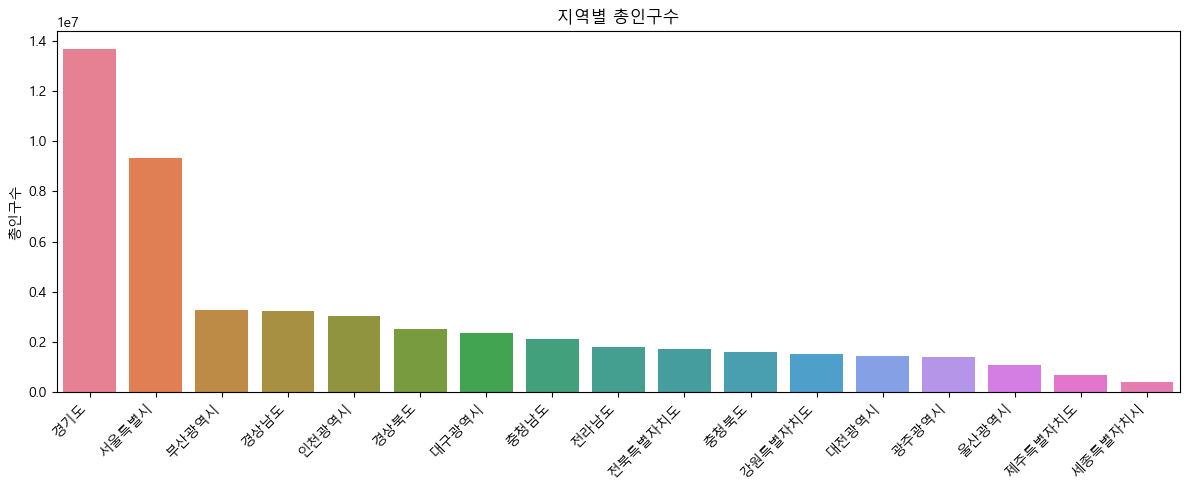

In [38]:
plot_display(df_region, '총인구수', title='지역별 총인구수')

## 2. 세대당 인구수 높은 지역 Top5

In [39]:
top5_household = get_top(df_region, '세대당 인구', cols=['행정기관', '세대당 인구'], reset_index=True)
top5_household

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


## 2-1. 지역별 세대당 인구 Plot

C:\Users\user\AppData\Local\Temp\ipykernel_21620\2062733429.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x='행정기관', y=column, palette='husl')


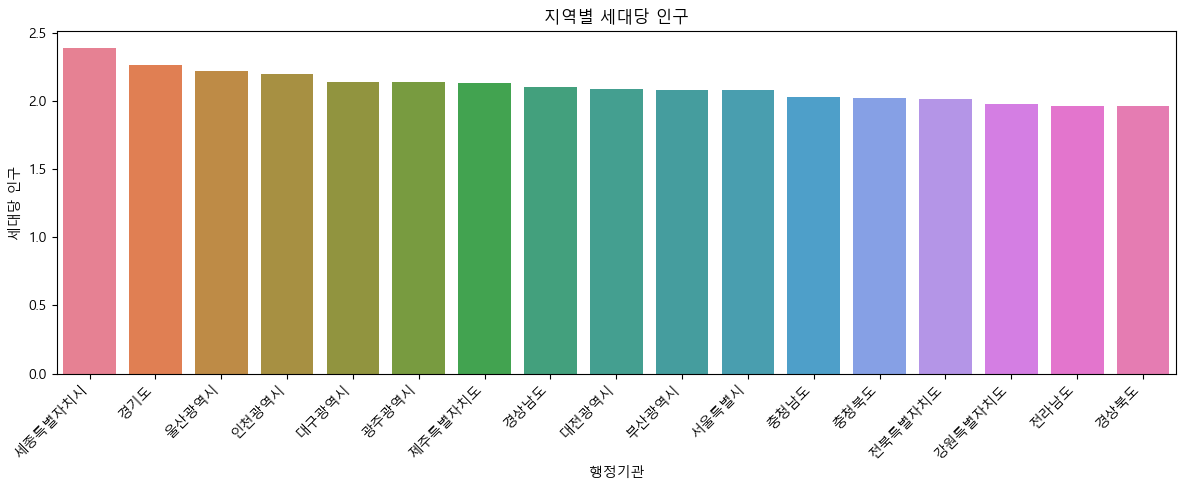

In [40]:
plot_display(df_region, '세대당 인구', xlabel='행정기관', title='지역별 세대당 인구')

## 3. 남녀 비율 분석

In [41]:
ratio = get_top(df_region, '남여 비율',cols=['행정기관', '남여 비율'],n=len(df_region), reset_index=True)
ratio

,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


## 3-1. 남녀 비율 분석 Plot

C:\Users\user\AppData\Local\Temp\ipykernel_21620\2062733429.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x='행정기관', y=column, palette='husl')


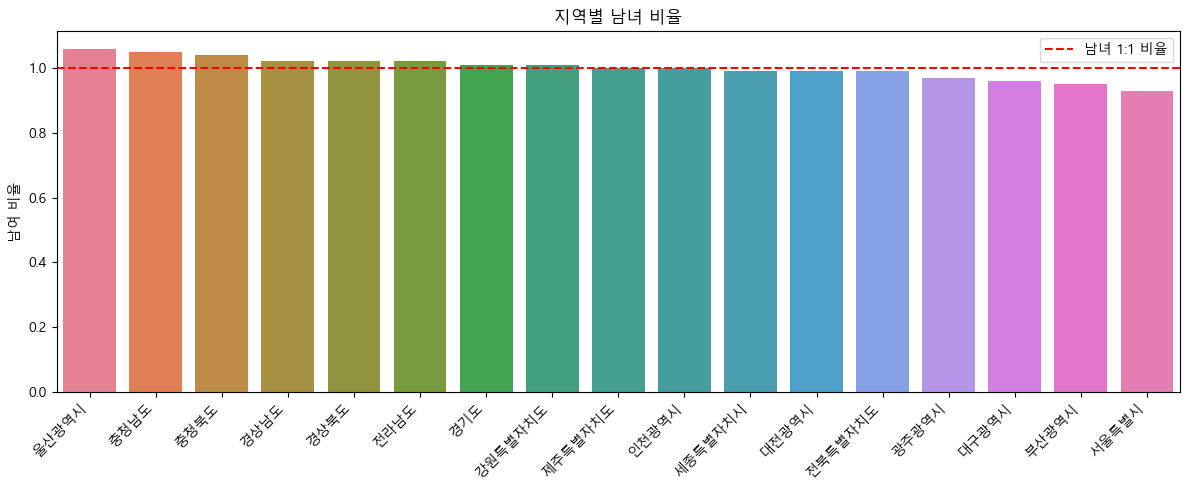

In [42]:
plot_display(df_region, '남여 비율', title='지역별 남녀 비율', ref_line=1.0, ref_label='남녀 1:1 비율')